## Heart Variability

as a proxy for Symphatic Nervous System

Challenge: find out sampling rate
best current guess: 500
* tapas/PhysIO/code/readin/tapas_physio_read_physlogfiles_philips.m : %default: 500 Hz sampling frequency
* 500 in Gökis .json file,
* but with 400 it the HRV plot beneath looks closer to the tutorial example! (peak at ~ 600 RR-intervals)


In [11]:
import neurokit2 as nk
import pandas as pd
import numpy as np
import os.path as op
import os
import matplotlib.pyplot as plt
import seaborn as sns

#bids_folder = '/Users/mrenke/data/ds-stressrisk'
bids_folder = '/mnt_01/ds-stressrisk'



In [13]:
sub = '01'
ses = 1
run = 2
fn = op.join(bids_folder, f'sub-{sub}', f'ses-{ses}', 'func', f'sub-{sub}_ses-{ses}_task-risk_run-{run}_physio.log')
ex_df = pd.read_csv(fn, delim_whitespace=True, header=4) # '\t'
ex_df.columns = list(ex_df.columns[1:]) + ['']
ex_df = ex_df.drop(columns='')
ex_df = ex_df.apply(pd.to_numeric, errors='coerce')

ex_df.head()

/tmp/ipykernel_1073689/277629033.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ex_df = pd.read_csv(fn, delim_whitespace=True, header=4) # '\t'
/tmp/ipykernel_1073689/277629033.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  ex_df = pd.read_csv(fn, delim_whitespace=True, header=4) # '\t'


,v1raw,v2raw,v1,v2,ppu,resp,gx,gy,gz,mark
0,-904.0,167.0,-11.0,-128.0,0.0,297.0,-655.0,-384.0,240.0,0.0
1,238.0,637.0,-32.0,-130.0,0.0,297.0,-946.0,-1022.0,-606.0,0.0
2,1329.0,585.0,-38.0,-131.0,0.0,287.0,-649.0,-1486.0,-2191.0,0.0
3,413.0,172.0,-53.0,-143.0,0.0,287.0,-533.0,-1181.0,-2594.0,0.0
4,-1204.0,-152.0,-67.0,-149.0,0.0,287.0,-605.0,-177.0,-714.0,0.0


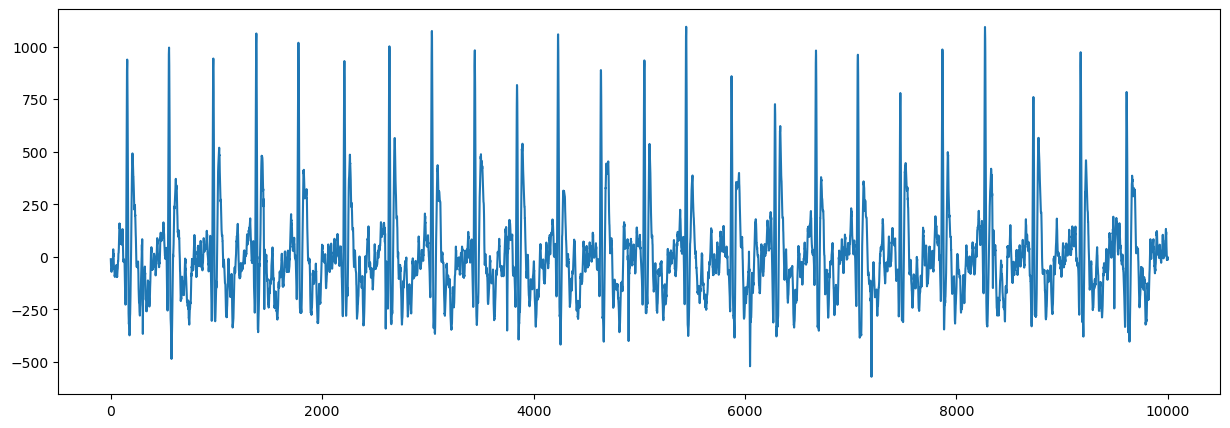

In [14]:
var = 'v1'

fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(ex_df[var][:10000])

In [ ]:
var = 'v2'
sampling_rate = 500
signals, info = nk.ecg_process( ex_df[var].values, sampling_rate=sampling_rate)
ecg_signal = signals['ECG_Clean'].values
peaks, info = nk.ecg_peaks(ecg_signal, sampling_rate=sampling_rate) # occurences of R-peaks are marked with 1 in a list of zeros; dictionary of the sample points at which these R-peaks occur

/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/neurokit2/ecg/ecg_clean.py:106: NeuroKitWarning: There are 1 missing data points in your signal. Filling missing values by using the forward filling method.
  warn(
/home/ubuntu/miniconda3/envs/basic_env_stressrisk_ana/lib/python3.13/site-packages/neurokit2/ecg/ecg_clean.py:165: FutureWarning: DataFrame.pad/Series.pad is deprecated. Use DataFrame.ffill/Series.ffill instead
  ecg_signal = pd.DataFrame.pad(pd.Series(ecg_signal))


HRV is the temporal variation between consecutive heartbeats (RR intervals)

* RMSSD (square root of the mean of the sum of successive differences between adjacent RR intervals), 
* MeanNN (mean of RR intervals) 

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_IQRNN,HRV_SDRMSSD,HRV_Prc20NN,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN
0,834.699153,70.812411,31.011907,62.079744,35.059254,63.98654,NaN,NaN,56.608463,56.668254,...,89.0,1.250916,778.0,889.2,25.0,59.957627,416.0,1090.0,16.857143,554.6875


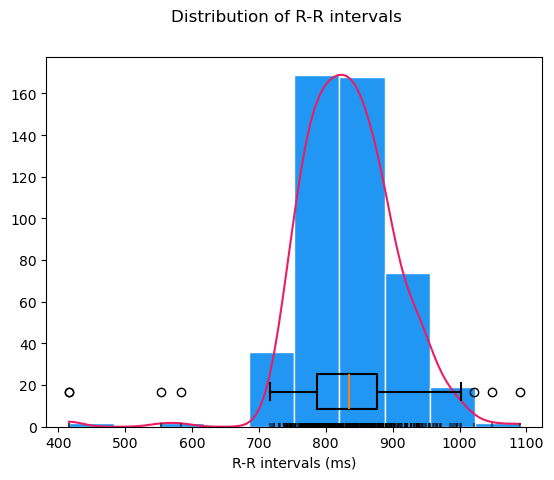

In [22]:
# Extract clean EDA and SCR features
hrv_time = nk.hrv_time(peaks, sampling_rate=sampling_rate, show=True)
hrv_time

0    1.203062
Name: HRV_LFHF, dtype: float64

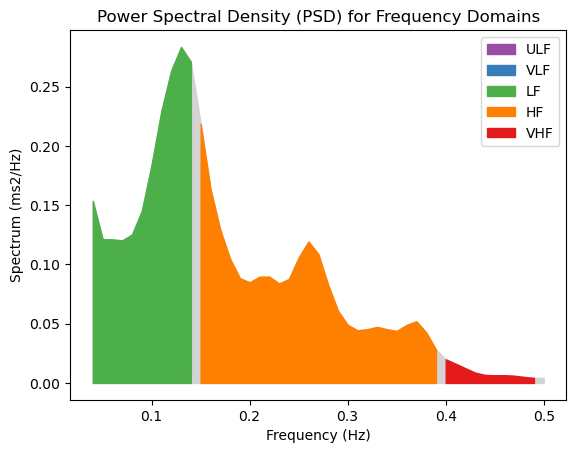

In [23]:
# Frequency domain analysis

hrv_freq = nk.hrv_frequency(peaks, sampling_rate=sampling_rate, show=True, normalize=True)
hrv_freq['HRV_LFHF']

In [24]:
hrv_freq

,HRV_ULF,HRV_VLF,HRV_LF,HRV_HF,HRV_VHF,HRV_TP,HRV_LFHF,HRV_LFn,HRV_HFn,HRV_LnHF
0,NaN,0.006066,0.007185,0.005972,0.000255,0.019477,1.203062,0.368879,0.306617,-5.120699


In [25]:
hrv_freq['HRV_LF']/hrv_freq['HRV_HF']

0    1.203062
dtype: float64

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_MSEn,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC
0,4173.495763,354.062057,221.122216,248.78342,201.329126,262.714232,155.059533,310.39872,283.042313,283.341269,...,1.468425,6.681559,1.063141,1.359782,1.320368,1.96825,1.537178,1.857765,2.685705,0.828043


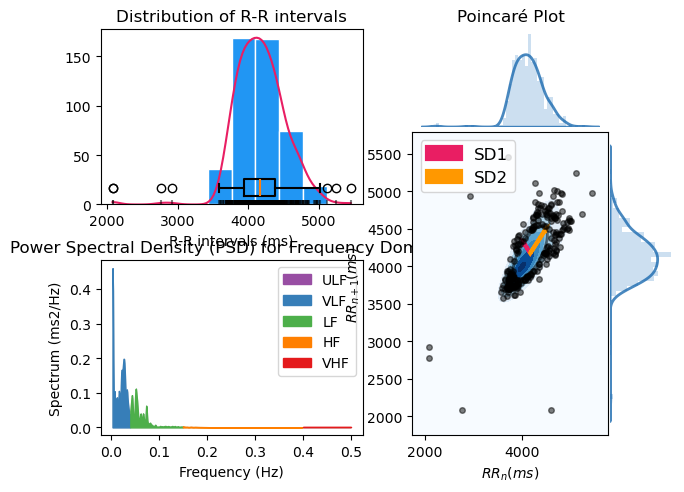

In [26]:
hrv_indices = nk.hrv(peaks, sampling_rate=100, show=True)
hrv_indices